# Сводный анализ сравнения моделей

Этот notebook является компактным аналитическим слоем для ВКР.

Что он делает:
- не переобучает модели;
- читает уже готовые benchmark/snapshot-артефакты из `experiments/model_comparison/`;
- читает отдельный production shortlist из `experiments/QA/production_runs/`;
- показывает краткую схему comparison-контура;
- собирает benchmark, `search_summary`, comparison snapshot-preview и
  отдельный production shortlist в одном месте.

Что он сознательно не делает:
- не дублирует preprocessing и EDA;
- не заменяет подробные логи и CSV-артефакты;
- не пытается пересказать весь проект целиком.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyBboxPatch

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def find_project_root(start: Path) -> Path:
    """Найти корень репозитория по маркерам проекта."""
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "Project root was not found. Expected README.md and pyproject.toml in parent directories."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUT_DIR = PROJECT_ROOT / "experiments" / "model_comparison"
PRODUCTION_OUTPUT_DIR = PROJECT_ROOT / "experiments" / "QA" / "production_runs"
BENCHMARK_RUN_NAME = "baseline_comparison_2026-03-19_v1_calibrated_limit5000"
SNAPSHOT_RUN_NAME = "baseline_comparison_2026-03-19_v1_calibrated_limit5000"
OPERATIONAL_RUN_NAME = "production_priority_2026-03-19_v1_calibrated_limit5000"
TOP_K = 50
SNAPSHOT_LIMIT = 5000

MODEL_ORDER = [
    "main_contrastive_v1",
    "baseline_random_forest",
    "baseline_mlp_small",
    "baseline_legacy_gaussian",
]
MODEL_LABELS = {
    "main_contrastive_v1": "Contrastive V1",
    "baseline_random_forest": "RandomForest",
    "baseline_mlp_small": "MLP small",
    "baseline_legacy_gaussian": "Legacy Gaussian",
}
MODEL_FAMILY = {
    "main_contrastive_v1": "Основная contrastive Gaussian-модель",
    "baseline_random_forest": "Классический ML baseline",
    "baseline_mlp_small": "Компактный ИНС baseline",
    "baseline_legacy_gaussian": "Исторический Gaussian baseline",
}
MODEL_COLORS = {
    "main_contrastive_v1": "#1f77b4",
    "baseline_random_forest": "#2ca02c",
    "baseline_mlp_small": "#ff7f0e",
    "baseline_legacy_gaussian": "#7f7f7f",
}

summary_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_summary.csv"
classwise_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_classwise.csv"
search_summary_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_search_summary.csv"
thresholds_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_thresholds.csv"
quality_summary_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_quality_summary.csv"
quality_classwise_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_quality_classwise.csv"
confusion_matrix_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_confusion_matrices.csv"
snapshot_summary_path = OUTPUT_DIR / f"{SNAPSHOT_RUN_NAME}_snapshot_summary.csv"
operational_shortlist_path = PRODUCTION_OUTPUT_DIR / f"{OPERATIONAL_RUN_NAME}_shortlist.csv"
operational_shortlist_summary_path = PRODUCTION_OUTPUT_DIR / f"{OPERATIONAL_RUN_NAME}_shortlist_summary.csv"
top_paths = {
    model_name: OUTPUT_DIR / f"{SNAPSHOT_RUN_NAME}_snapshot_{model_name}_top.csv"
    for model_name in MODEL_ORDER
}

required_paths = [
    summary_path,
    classwise_path,
    search_summary_path,
    thresholds_path,
    quality_summary_path,
    quality_classwise_path,
    confusion_matrix_path,
    snapshot_summary_path,
    operational_shortlist_path,
    operational_shortlist_summary_path,
    *top_paths.values(),
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        "Comparison artifacts not found:\n"
        f"{missing_text}\n\n"
        "If artifacts were not generated yet, run:\n"
        f"  python -m analysis.model_comparison --run-name {BENCHMARK_RUN_NAME}\n"
        f"  python -m analysis.model_comparison --run-name {SNAPSHOT_RUN_NAME} --skip-snapshot\n"
        f"  python -m priority_pipeline.export --run-name {OPERATIONAL_RUN_NAME} --limit {SNAPSHOT_LIMIT}"
    )

summary_df = pd.read_csv(summary_path, low_memory=False)
classwise_df = pd.read_csv(classwise_path, low_memory=False)
search_summary_df = pd.read_csv(search_summary_path, low_memory=False)
thresholds_df = pd.read_csv(thresholds_path, low_memory=False)
quality_summary_df = pd.read_csv(quality_summary_path, low_memory=False)
quality_classwise_df = pd.read_csv(quality_classwise_path, low_memory=False)
confusion_matrix_df = pd.read_csv(confusion_matrix_path, low_memory=False)
snapshot_summary_df = pd.read_csv(snapshot_summary_path, low_memory=False)
operational_shortlist_df = pd.read_csv(operational_shortlist_path, low_memory=False)
operational_shortlist_summary_df = pd.read_csv(operational_shortlist_summary_path, low_memory=False)

test_summary_df = (
    summary_df.loc[summary_df["split_name"] == "test"].copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
    .assign(model_family=lambda df: df["model_name"].map(MODEL_FAMILY))
)
test_summary_df["model_label"] = pd.Categorical(
    test_summary_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
test_summary_df = test_summary_df.sort_values("model_label").reset_index(drop=True)

classwise_test_df = (
    classwise_df.loc[classwise_df["split_name"] == "test"].copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
classwise_test_df["model_label"] = pd.Categorical(
    classwise_test_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
classwise_test_df = classwise_test_df.sort_values(["model_label", "spec_class"]).reset_index(drop=True)

thresholds_df = (
    thresholds_df.copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
thresholds_df["model_label"] = pd.Categorical(
    thresholds_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
thresholds_df = thresholds_df.sort_values("model_label").reset_index(drop=True)

test_quality_df = (
    quality_summary_df.loc[quality_summary_df["split_name"] == "test"].copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
test_quality_df["model_label"] = pd.Categorical(
    test_quality_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
test_quality_df = test_quality_df.sort_values("model_label").reset_index(drop=True)

classwise_test_quality_df = (
    quality_classwise_df.loc[quality_classwise_df["split_name"] == "test"].copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
classwise_test_quality_df["model_label"] = pd.Categorical(
    classwise_test_quality_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
classwise_test_quality_df = classwise_test_quality_df.sort_values(
    ["model_label", "spec_class"]
).reset_index(drop=True)

confusion_test_df = (
    confusion_matrix_df.loc[
        (confusion_matrix_df["split_name"] == "test")
        & (confusion_matrix_df["quality_scope"] == "overall")
    ]
    .copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
confusion_test_df["model_label"] = pd.Categorical(
    confusion_test_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
confusion_test_df = confusion_test_df.sort_values(
    ["model_label", "actual_label", "predicted_label"]
).reset_index(drop=True)

search_summary_df = (
    search_summary_df.copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
    .assign(spec_class=lambda df: df["spec_class"].fillna("all"))
)
search_summary_df["model_label"] = pd.Categorical(
    search_summary_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
search_summary_df = search_summary_df.sort_values(["model_label", "search_scope", "spec_class"]).reset_index(drop=True)

snapshot_summary_df = (
    snapshot_summary_df.copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
snapshot_summary_df["model_label"] = pd.Categorical(
    snapshot_summary_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
snapshot_summary_df = snapshot_summary_df.sort_values("model_label").reset_index(drop=True)

top_frames = {
    model_name: pd.read_csv(path, low_memory=False)
    for model_name, path in top_paths.items()
}

snapshot_context = snapshot_summary_df.iloc[0][[
    "input_rows",
    "router_rows",
    "host_candidates",
    "low_known_rows",
    "unknown_rows",
]]

comparison_overview_df = (
    test_summary_df[
        ["model_name", "model_label", "model_family", "roc_auc", "pr_auc", "brier", "precision_at_k"]
    ]
    .merge(
        snapshot_summary_df[
            ["model_name", "high_rows", "medium_rows", "low_rows", "top_final_score"]
        ],
        on="model_name",
        how="left",
    )
)
comparison_overview_df

,model_name,model_label,model_family,roc_auc,pr_auc,brier,precision_at_k,high_rows,medium_rows,low_rows,top_final_score
0,main_contrastive_v1,Contrastive V1,Основная contrastive Gaussian-модель,0.867370,0.590399,0.154324,0.72,243,1199,3558,0.777914
1,baseline_random_forest,RandomForest,Классический ML baseline,0.932604,0.761796,0.090081,0.92,744,794,3462,0.922032
2,baseline_mlp_small,MLP small,Компактный ИНС baseline,0.922728,0.755534,0.090139,0.92,402,865,3733,0.898703
3,baseline_legacy_gaussian,Legacy Gaussian,Исторический Gaussian baseline,0.846410,0.571297,0.148316,0.72,141,1109,3750,0.762134


## Упрощённая схема comparison-контура

Ниже показана именно логика сравнительного прогона моделей.

Идея такая:
- входной relation один и тот же;
- `router + OOD` общий;
- внутри host-ветки работают разные model head;
- downstream orchestrator общий для всех;
- дальше идёт единый аналитический слой.


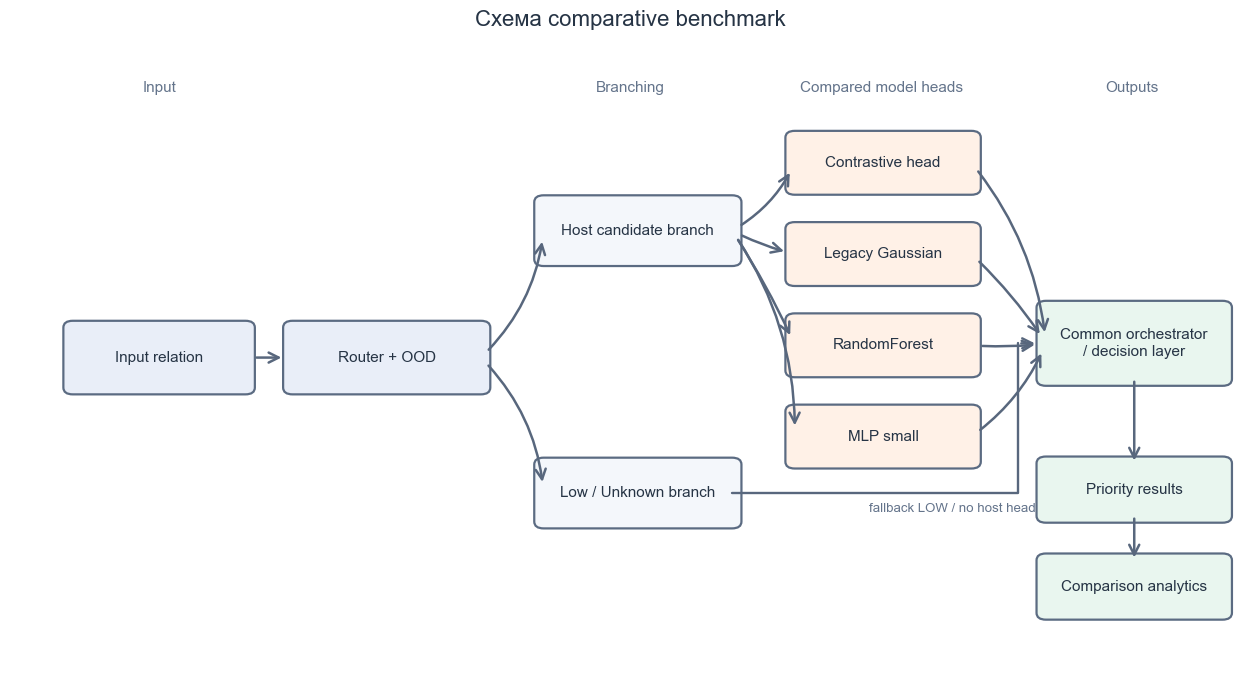

In [2]:
fig, ax = plt.subplots(figsize=(16, 8), facecolor="white")
ax.set_xlim(0, 15.8)
ax.set_ylim(0, 10.8)
ax.axis("off")

EDGE = "#5b6b82"
TEXT = "#263445"
ARROW = "#58677d"
PALETTE = {
    "input": "#e9eef8",
    "branch": "#f4f7fb",
    "head": "#fff1e7",
    "output": "#e9f6ef",
}

boxes = {
    "input": (0.8, 4.9, 2.2, 1.05, "Input relation", "input"),
    "router": (3.6, 4.9, 2.4, 1.05, "Router + OOD", "input"),
    "host": (6.8, 7.15, 2.4, 1.0, "Host candidate branch", "branch"),
    "low": (6.8, 2.55, 2.4, 1.0, "Low / Unknown branch", "branch"),
    "contrastive": (10.0, 8.4, 2.25, 0.88, "Contrastive head", "head"),
    "legacy": (10.0, 6.8, 2.25, 0.88, "Legacy Gaussian", "head"),
    "rf": (10.0, 5.2, 2.25, 0.88, "RandomForest", "head"),
    "mlp": (10.0, 3.6, 2.25, 0.88, "MLP small", "head"),
    "orchestrator": (13.2, 5.05, 2.25, 1.25, "Common orchestrator\n/ decision layer", "output"),
    "results": (13.2, 2.65, 2.25, 0.92, "Priority results", "output"),
    "analytics": (13.2, 0.95, 2.25, 0.92, "Comparison analytics", "output"),
}


def add_box(x, y, w, h, label, color_key):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.12,rounding_size=0.12",
        linewidth=1.6,
        edgecolor=EDGE,
        facecolor=PALETTE[color_key],
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        color=TEXT,
    )


for _, (x, y, w, h, label, color_key) in boxes.items():
    add_box(x, y, w, h, label, color_key)

ax.text(1.9, 10.15, "Input", ha="center", va="center", fontsize=11, color="#64748b")
ax.text(7.9, 10.15, "Branching", ha="center", va="center", fontsize=11, color="#64748b")
ax.text(11.1, 10.15, "Compared model heads", ha="center", va="center", fontsize=11, color="#64748b")
ax.text(14.3, 10.15, "Outputs", ha="center", va="center", fontsize=11, color="#64748b")



def mid_left(name):
    x, y, w, h, _, _ = boxes[name]
    return x, y + h / 2



def mid_right(name):
    x, y, w, h, _, _ = boxes[name]
    return x + w, y + h / 2



def connect(src, dst, rad=0.0, lw=1.8):
    ax.annotate(
        "",
        xy=mid_left(dst),
        xytext=mid_right(src),
        arrowprops=dict(
            arrowstyle="->",
            lw=lw,
            color=ARROW,
            shrinkA=8,
            shrinkB=8,
            connectionstyle=f"arc3,rad={rad}",
        ),
    )



def connect_routed(src, route_points, dst, lw=1.8):
    points = [mid_right(src), *route_points]
    xs, ys = zip(*points)
    ax.plot(xs, ys, color=ARROW, lw=lw, solid_capstyle="round")
    ax.annotate(
        "",
        xy=mid_left(dst),
        xytext=points[-1],
        arrowprops=dict(
            arrowstyle="->",
            lw=lw,
            color=ARROW,
            shrinkA=2,
            shrinkB=8,
        ),
    )


connect("input", "router")
connect("router", "host", rad=0.18)
connect("router", "low", rad=-0.18)

connect("host", "contrastive", rad=0.16)
connect("host", "legacy", rad=0.06)
connect("host", "rf", rad=-0.04)
connect("host", "mlp", rad=-0.16)

connect("contrastive", "orchestrator", rad=-0.15)
connect("legacy", "orchestrator", rad=-0.06)
connect("rf", "orchestrator", rad=0.05)
connect("mlp", "orchestrator", rad=0.14)
connect_routed(
    "low",
    [(9.55, 3.05), (12.85, 3.05), (12.85, 5.675)],
    "orchestrator",
    lw=1.7,
)

ax.text(10.95, 2.72, "fallback LOW / no host head", fontsize=9.5, color="#64748b")

ax.annotate(
    "",
    xy=(14.325, 3.57),
    xytext=(14.325, 5.05),
    arrowprops=dict(arrowstyle="->", lw=1.8, color=ARROW),
)
ax.annotate(
    "",
    xy=(14.325, 1.87),
    xytext=(14.325, 2.65),
    arrowprops=dict(arrowstyle="->", lw=1.8, color=ARROW),
)

ax.set_title("Схема comparative benchmark", fontsize=16, pad=18, color=TEXT)
plt.show()


## Что именно сравниваем

В notebook сравниваются четыре model head на одном и том же benchmark и
на одном и том же downstream orchestrator.

Для benchmark используется уже обновлённый ВКР-контракт:
- `test_size = 0.30`;
- `10-fold CV` внутри train split;
- отдельный `search_summary` с best params.


In [3]:
comparison_overview_df.rename(
    columns={
        "model_label": "Модель",
        "model_family": "Роль в работе",
        "roc_auc": "ROC-AUC (test)",
        "pr_auc": "PR-AUC (test)",
        "brier": "Brier (test)",
        "precision_at_k": "precision@50 (test)",
        "high_rows": "HIGH",
        "medium_rows": "MEDIUM",
        "low_rows": "LOW",
        "top_final_score": "top final score",
    }
)


,model_name,Модель,Роль в работе,ROC-AUC (test),PR-AUC (test),Brier (test),precision@50 (test),HIGH,MEDIUM,LOW,top final score
0,main_contrastive_v1,Contrastive V1,Основная contrastive Gaussian-модель,0.867370,0.590399,0.154324,0.72,243,1199,3558,0.777914
1,baseline_random_forest,RandomForest,Классический ML baseline,0.932604,0.761796,0.090081,0.92,744,794,3462,0.922032
2,baseline_mlp_small,MLP small,Компактный ИНС baseline,0.922728,0.755534,0.090139,0.92,402,865,3733,0.898703
3,baseline_legacy_gaussian,Legacy Gaussian,Исторический Gaussian baseline,0.846410,0.571297,0.148316,0.72,141,1109,3750,0.762134


## Supervised benchmark

Здесь сравниваются численные test-метрики на задаче `host vs field`.

Важно: это уже не старая волна `baseline_comparison_2026-03-13_mlp`, а
текущий канонический run `baseline_comparison_2026-03-19_v1_calibrated_limit5000`.


In [4]:
method_contract_df = pd.DataFrame(
    [
        {"Параметр": "Benchmark run", "Значение": BENCHMARK_RUN_NAME},
        {"Параметр": "test_size", "Значение": "0.30"},
        {"Параметр": "cv_folds", "Значение": "10"},
        {"Параметр": "cv_random_state", "Значение": "42"},
        {"Параметр": "search_refit_metric", "Значение": "roc_auc"},
        {"Параметр": "precision@k", "Значение": str(TOP_K)},
        {"Параметр": "Snapshot preview run", "Значение": SNAPSHOT_RUN_NAME},
        {"Параметр": "snapshot_limit", "Значение": str(SNAPSHOT_LIMIT)},
        {"Параметр": "Operational export run", "Значение": OPERATIONAL_RUN_NAME},
    ]
)
method_contract_df

,Параметр,Значение
0,Benchmark run,baseline_comparison_2026-03-19_v1_calibrated_l...
1,test_size,0.30
2,cv_folds,10
3,cv_random_state,42
4,search_refit_metric,roc_auc
5,precision@k,50
6,Snapshot preview run,baseline_comparison_2026-03-19_v1_calibrated_l...
7,snapshot_limit,5000
8,Operational export run,production_priority_2026-03-19_v1_calibrated_l...


In [5]:
benchmark_table = test_summary_df[
    ["model_label", "roc_auc", "pr_auc", "brier", "precision_at_k"]
].rename(
    columns={
        "model_label": "Модель",
        "roc_auc": "ROC-AUC",
        "pr_auc": "PR-AUC",
        "brier": "Brier",
        "precision_at_k": "precision@50",
    }
)
benchmark_table


,Модель,ROC-AUC,PR-AUC,Brier,precision@50
0,Contrastive V1,0.867370,0.590399,0.154324,0.72
1,RandomForest,0.932604,0.761796,0.090081,0.92
2,MLP small,0.922728,0.755534,0.090139,0.92
3,Legacy Gaussian,0.846410,0.571297,0.148316,0.72


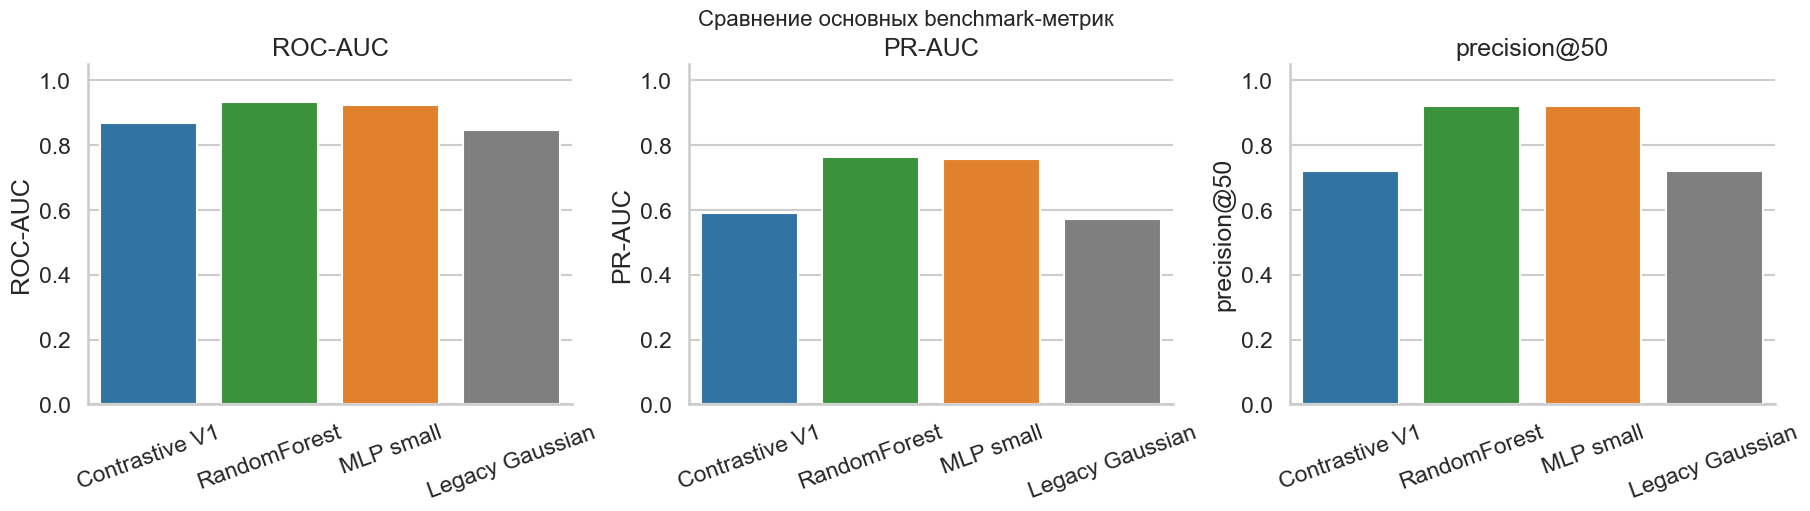

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
metric_specs = [
    ("roc_auc", "ROC-AUC"),
    ("pr_auc", "PR-AUC"),
    ("precision_at_k", "precision@50"),
]
for ax, (metric, title) in zip(axes, metric_specs):
    sns.barplot(
        data=test_summary_df,
        x="model_label",
        y=metric,
        hue="model_name",
        palette=MODEL_COLORS,
        dodge=False,
        ax=ax,
    )
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(0, 1.05)
fig.suptitle("Сравнение основных benchmark-метрик", fontsize=16)
plt.show()


## Threshold-based quality

Этот блок дополняет `ROC-AUC / PR-AUC` уже пороговыми метриками классификации. Порог выбирается только на `train` split по `max F1`, после чего фиксируется и применяется к `test`.

Здесь смотрим на компактный набор: `precision`, `recall`, `f1`, `specificity`, `balanced_accuracy`, а также на итоговую confusion matrix.

In [7]:
threshold_view_df = thresholds_df[["model_label", "threshold_value", "threshold_score"]].rename(
    columns={
        "model_label": "Модель",
        "threshold_value": "Train threshold",
        "threshold_score": "Train F1 at threshold",
    }
).copy()
threshold_view_df[["Train threshold", "Train F1 at threshold"]] = threshold_view_df[[
    "Train threshold",
    "Train F1 at threshold",
]].round(4)

quality_view_df = test_quality_df[[
    "model_label",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
    "accuracy",
]].rename(columns={
    "model_label": "Модель",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "specificity": "Specificity",
    "balanced_accuracy": "Balanced accuracy",
    "accuracy": "Accuracy",
}).copy()
quality_view_df[["Precision", "Recall", "F1", "Specificity", "Balanced accuracy", "Accuracy"]] = quality_view_df[[
    "Precision", "Recall", "F1", "Specificity", "Balanced accuracy", "Accuracy"
]].round(4)

confusion_view_df = (
    confusion_test_df.assign(
        confusion_label=lambda df: df.apply(
            lambda row: "TP" if row["actual_label"] and row["predicted_label"] else (
                "FP" if (not row["actual_label"]) and row["predicted_label"] else (
                    "TN" if (not row["actual_label"]) and (not row["predicted_label"]) else "FN"
                )
            ),
            axis=1,
        )
    )
    .pivot(index="model_label", columns="confusion_label", values="n_rows")
    .reset_index()
    .rename(columns={"model_label": "Модель"})
    [["Модель", "TP", "FP", "TN", "FN"]]
)

display(threshold_view_df)
display(quality_view_df)
display(confusion_view_df)

,Модель,Train threshold,Train F1 at threshold
0,Contrastive V1,0.4987,0.6308
1,RandomForest,0.6133,0.9369
2,MLP small,0.3567,0.7418
3,Legacy Gaussian,0.3839,0.6020


,Модель,Precision,Recall,F1,Specificity,Balanced accuracy,Accuracy
0,Contrastive V1,0.4823,0.8665,0.6196,0.7367,0.8016,0.7653
1,RandomForest,0.7172,0.7193,0.7183,0.9197,0.8195,0.8755
2,MLP small,0.6783,0.7841,0.7274,0.8947,0.8394,0.8703
3,Legacy Gaussian,0.5136,0.7036,0.5938,0.8114,0.7575,0.7876


confusion_label,Модель,TP,FP,TN,FN
0,Contrastive V1,883,948,2652,136
1,RandomForest,733,289,3311,286
2,MLP small,799,379,3221,220
3,Legacy Gaussian,717,679,2921,302


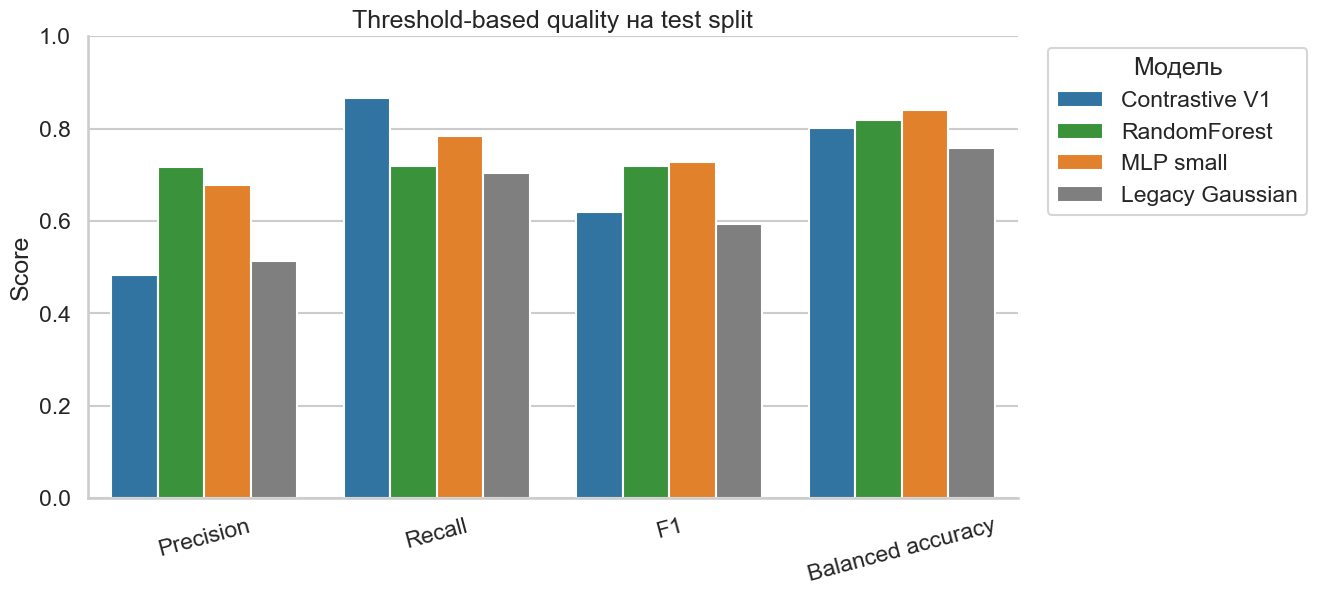

In [8]:
quality_plot_df = test_quality_df[[
    "model_label", "precision", "recall", "f1", "balanced_accuracy"
]].rename(columns={"model_label": "Модель"}).melt(
    id_vars="Модель",
    var_name="metric_name",
    value_name="metric_value",
)

metric_labels = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "balanced_accuracy": "Balanced accuracy",
}
quality_plot_df["metric_label"] = quality_plot_df["metric_name"].map(metric_labels)
quality_plot_df["Модель"] = pd.Categorical(
    quality_plot_df["Модель"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=quality_plot_df,
    x="metric_label",
    y="metric_value",
    hue="Модель",
    palette={MODEL_LABELS[name]: MODEL_COLORS[name] for name in MODEL_ORDER},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("Threshold-based quality на test split")
ax.set_ylim(0.0, 1.0)
ax.legend(title="Модель", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15)
plt.show()

## Search-контракт и выбранные параметры

С новой версией comparison-layer benchmark больше не ограничивается только
численными test-метриками. Теперь в notebook явно показано:
- что benchmark использует `test_size = 0.30`;
- что подбор параметров идёт через `10-fold CV` внутри train split;
- что для `RF/MLP` используется `GridSearchCV`, а для Gaussian-моделей —
  эквивалентный manual search;
- какие best params реально выбраны на новых артефактах.


In [9]:
search_summary_view_df = search_summary_df[
    [
        "model_label",
        "search_scope",
        "spec_class",
        "refit_metric",
        "cv_folds",
        "candidate_count",
        "best_cv_score",
        "best_params_json",
    ]
].rename(
    columns={
        "model_label": "Модель",
        "search_scope": "Масштаб поиска",
        "spec_class": "spec_class",
        "refit_metric": "Refit metric",
        "cv_folds": "CV folds",
        "candidate_count": "Число кандидатов",
        "best_cv_score": "Лучший CV score",
        "best_params_json": "best_params",
    }
)
search_summary_view_df

,Модель,Масштаб поиска,spec_class,Refit metric,CV folds,Число кандидатов,Лучший CV score,best_params
0,Contrastive V1,model,all,roc_auc,10,8,0.875410,"{""min_population_size"": 2, ""shrink_alpha"": 0.0..."
1,RandomForest,class,F,roc_auc,10,6,0.861399,"{""min_samples_leaf"": 4, ""n_estimators"": 300}"
2,RandomForest,class,G,roc_auc,10,6,0.902537,"{""min_samples_leaf"": 1, ""n_estimators"": 300}"
3,RandomForest,class,K,roc_auc,10,6,0.961211,"{""min_samples_leaf"": 4, ""n_estimators"": 100}"
4,RandomForest,class,M,roc_auc,10,6,0.923160,"{""min_samples_leaf"": 4, ""n_estimators"": 300}"
5,MLP small,class,F,roc_auc,10,6,0.737762,"{""alpha"": 0.01, ""hidden_layer_sizes"": [16, 8]}"
6,MLP small,class,G,roc_auc,10,6,0.904066,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [16, 8]}"
7,MLP small,class,K,roc_auc,10,6,0.960198,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [8, 4]}"
8,MLP small,class,M,roc_auc,10,6,0.904849,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [16, 8]}"
9,Legacy Gaussian,model,all,roc_auc,10,6,0.843709,"{""shrink_alpha"": 0.15, ""use_m_subclasses"": true}"


## Class-wise качество

Компактный class-wise блок показывает два ракурса одной и той же картины: `PR-AUC` как ranking-метрику и `balanced_accuracy` как уже пороговое quality-поведение на классах `M/K/G/F`. Такой срез помогает быстро увидеть, где модель не только ранжирует, но и устойчиво классифицирует кандидатов.

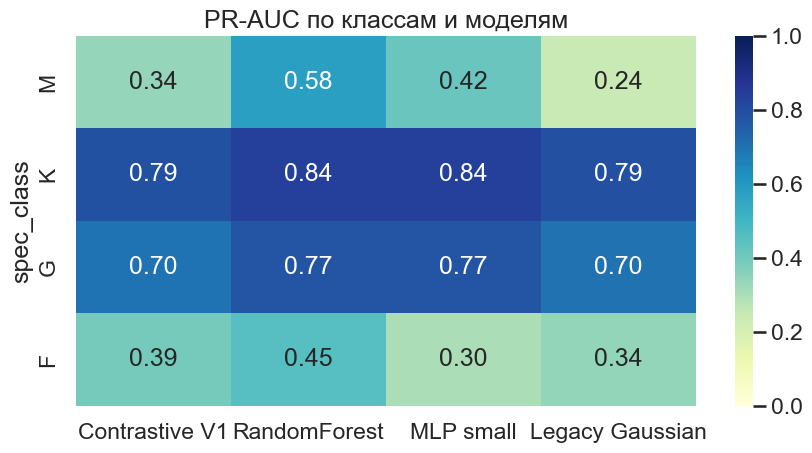

model_label,Contrastive V1,RandomForest,MLP small,Legacy Gaussian
spec_class,,,,
M,0.339432,0.575353,0.420101,0.244128
K,0.787895,0.839429,0.836176,0.790200
G,0.696463,0.774714,0.773902,0.701825
F,0.393108,0.454630,0.297167,0.340285


In [10]:
classwise_heatmap_df = (
    classwise_test_df.pivot(index="spec_class", columns="model_label", values="pr_auc")
    .reindex(index=["M", "K", "G", "F"])
    .reindex(columns=[MODEL_LABELS[name] for name in MODEL_ORDER])
)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    classwise_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    ax=ax,
)
ax.set_title("PR-AUC по классам и моделям")
ax.set_xlabel("")
ax.set_ylabel("spec_class")
plt.show()
classwise_heatmap_df


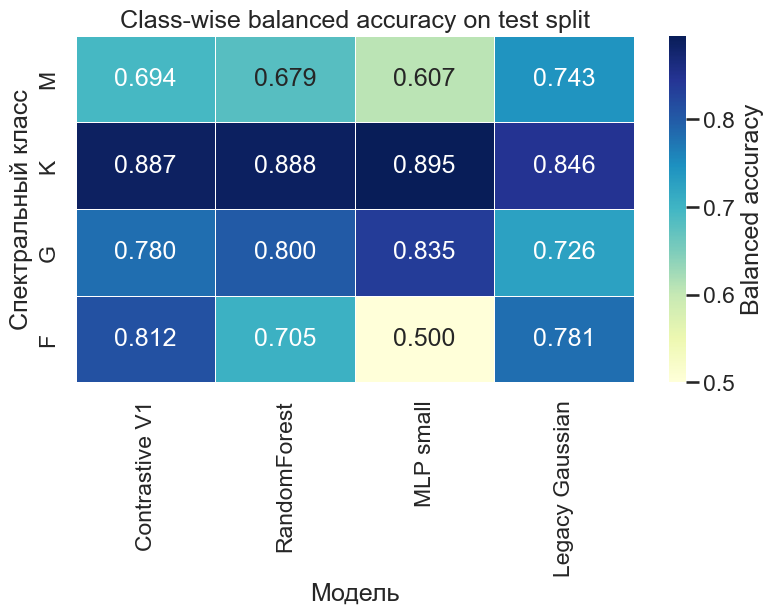

In [11]:
classwise_quality_heatmap_df = (
    classwise_test_quality_df.pivot(
        index="spec_class",
        columns="model_label",
        values="balanced_accuracy",
    )
    .reindex(index=["M", "K", "G", "F"])
    [[MODEL_LABELS[name] for name in MODEL_ORDER]]
)

plt.figure(figsize=(9, 4.5))
sns.heatmap(
    classwise_quality_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Balanced accuracy"},
)
plt.title("Class-wise balanced accuracy on test split")
plt.xlabel("Модель")
plt.ylabel("Спектральный класс")
plt.show()

## Snapshot после общего оркестратора

Здесь уже показывается operational view: один и тот же `router + OOD`,
один и тот же downstream orchestrator, но разные model head внутри
host-ветки.

В текущей редакции notebook используется не полный relation, а
оперативный preview с `snapshot_limit = 5000`. Для ВКР это удобнее,
потому что он быстрее воспроизводится и даёт те же качественные выводы
по характеру ranking-а.


In [12]:
snapshot_context.to_frame(name="value")


,value
input_rows,5000
router_rows,5000
host_candidates,4202
low_known_rows,769
unknown_rows,29


In [13]:
snapshot_summary_df[
    ["model_label", "high_rows", "medium_rows", "low_rows", "top_final_score"]
].rename(
    columns={
        "model_label": "Модель",
        "high_rows": "HIGH",
        "medium_rows": "MEDIUM",
        "low_rows": "LOW",
        "top_final_score": "top final score",
    }
)


,Модель,HIGH,MEDIUM,LOW,top final score
0,Contrastive V1,243,1199,3558,0.777914
1,RandomForest,744,794,3462,0.922032
2,MLP small,402,865,3733,0.898703
3,Legacy Gaussian,141,1109,3750,0.762134


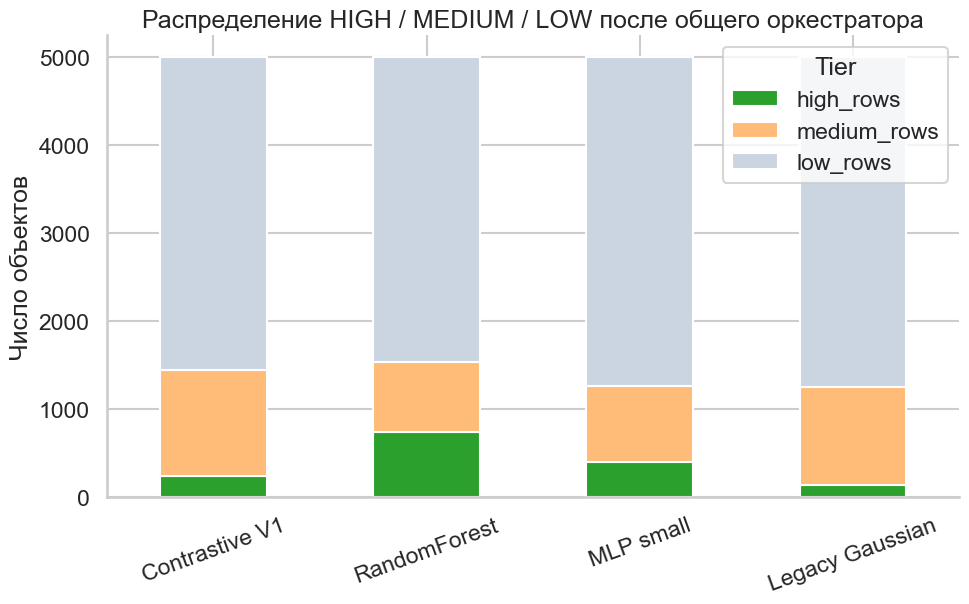

In [14]:
tier_plot_df = snapshot_summary_df[["model_label", "high_rows", "medium_rows", "low_rows"]].copy()
tier_plot_df = tier_plot_df.rename(columns={"model_label": "Модель"}).set_index("Модель")
fig, ax = plt.subplots(figsize=(11, 6))
tier_plot_df.plot(
    kind="bar",
    stacked=True,
    color=["#2ca02c", "#ffbb78", "#cbd5e1"],
    ax=ax,
)
ax.set_title("Распределение HIGH / MEDIUM / LOW после общего оркестратора")
ax.set_xlabel("")
ax.set_ylabel("Число объектов")
ax.legend(title="Tier")
ax.tick_params(axis="x", rotation=20)
plt.show()


## Согласие и расхождение моделей

В этом блоке оценивается, насколько модели совпадают по `top-k` после
общего оркестратора.

Такой срез особенно полезен для презентации: он показывает не только
"кто победил по ROC-AUC", но и где модели реально поддерживают одни и
те же follow-up кандидаты.


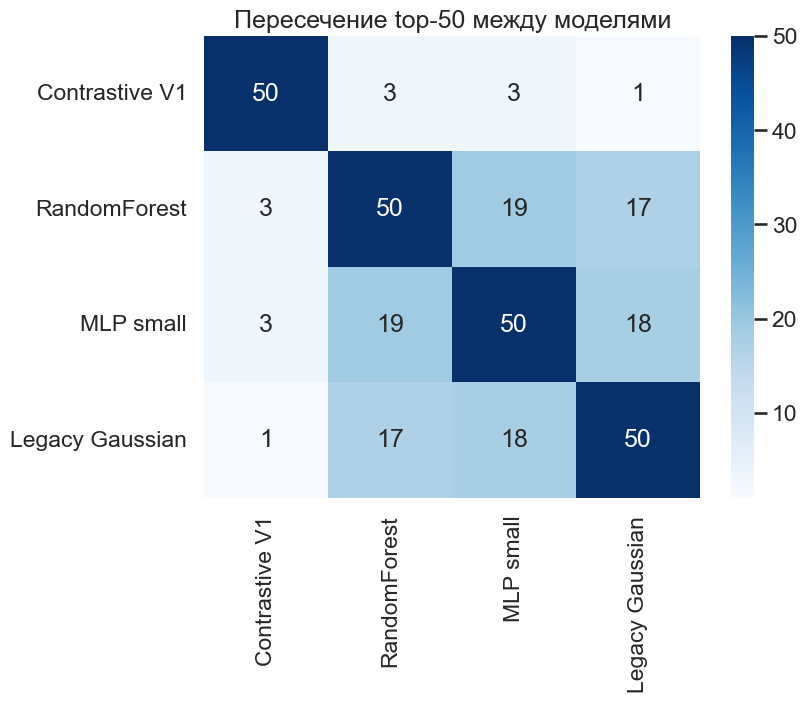

,Contrastive V1,RandomForest,MLP small,Legacy Gaussian
Contrastive V1,50.0,3.0,3.0,1.0
RandomForest,3.0,50.0,19.0,17.0
MLP small,3.0,19.0,50.0,18.0
Legacy Gaussian,1.0,17.0,18.0,50.0


In [15]:
overlap_matrix = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
for left_name in MODEL_ORDER:
    left_ids = set(top_frames[left_name]["source_id"].tolist())
    for right_name in MODEL_ORDER:
        right_ids = set(top_frames[right_name]["source_id"].tolist())
        overlap_matrix.loc[left_name, right_name] = len(left_ids & right_ids)

overlap_matrix = overlap_matrix.rename(index=MODEL_LABELS, columns=MODEL_LABELS)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title(f"Пересечение top-{TOP_K} между моделями")
plt.show()
overlap_matrix


In [16]:
support_rows = []
for model_name, top_df in top_frames.items():
    current = top_df[["source_id", "predicted_spec_class", "final_score"]].copy()
    current["model_name"] = model_name
    support_rows.append(current)

support_df = pd.concat(support_rows, ignore_index=True, sort=False)

def format_model_set(values: pd.Series) -> str:
    ordered = sorted(set(values), key=MODEL_ORDER.index)
    return ", ".join(MODEL_LABELS[name] for name in ordered)

disagreement_df = (
    support_df.groupby("source_id")
    .agg(
        spec_class=("predicted_spec_class", "first"),
        best_final_score=("final_score", "max"),
        n_models=("model_name", "nunique"),
        models=("model_name", format_model_set),
    )
    .reset_index()
)

unique_top_candidates_df = disagreement_df.loc[disagreement_df["n_models"] == 1].copy()
unique_top_candidates_df = unique_top_candidates_df.sort_values(
    ["best_final_score", "source_id"],
    ascending=[False, True],
    ignore_index=True,
).head(10)

consensus_top_candidates_df = disagreement_df.loc[disagreement_df["n_models"] >= 3].copy()
consensus_top_candidates_df = consensus_top_candidates_df.sort_values(
    ["n_models", "best_final_score"],
    ascending=[False, False],
    ignore_index=True,
).head(10)

examples_df = pd.concat(
    {
        "unique_top_candidates": unique_top_candidates_df,
        "consensus_top_candidates": consensus_top_candidates_df,
    },
    names=["section"],
)
examples_df


source_id spec_class  best_final_score  \
section                                                                        
unique_top_candidates    0   489552059008119040          K          0.913963   
                         1  1308974472679778304          K          0.905135   
                         2  1838250709974693376          K          0.901063   
                         3  1817487777212366976          K          0.889013   
                         4  1953422461338390016          K          0.874443   
                         5   379724282049084928          K          0.870470   
                         6  1970541582515682304          K          0.869581   
                         7    84191877377264384          K          0.868731   
                         8   975039047427822208          K          0.863863   
                         9   231638173373335168          K          0.862209   
consensus_top_candidates 0  2009812976760907136          K          0.879388   
                         1  1970498667200180352          K          0.922032   
                         2  1816493440755009536          K          0.903044   
                         3   422188486273959552          K          0.898703   
                         4  1863187534912698624          K          0.889752   
                         5  1865964622110670976          K          0.885445   
                         6    59318278657519232          K          0.879955   
                         7  2054919307419256576          K          0.878755   
                         8  2062037167754480640          K          0.878491   
                         9    54884979056532608          K          0.877545   

                            n_models  \
section                                
unique_top_candidates    0         1   
                         1         1   
                         2         1   
                         3         1   
                         4         1   
                         5         1   
                         6         1   
                         7         1   
                         8         1   
                         9         1   
consensus_top_candidates 0         4   
                         1         3   
                         2         3   
                         3         3   
                         4         3   
                         5         3   
                         6         3   
                         7         3   
                         8         3   
                         9         3   

                                                                       models  
section                                                                        
unique_top_candidates    0                                       RandomForest  
                         1                                       RandomForest  
                         2                                       RandomForest  
                         3                                       RandomForest  
                         4                                       RandomForest  
                         5                                       RandomForest  
                         6                                       RandomForest  
                         7                                       RandomForest  
                         8                                       RandomForest  
                         9                                       RandomForest  
consensus_top_candidates 0  Contrastive V1, RandomForest, MLP small, Legac...  
                         1           RandomForest, MLP small, Legacy Gaussian  
                         2           RandomForest, MLP small, Legacy Gaussian  
                         3            Contrastive V1, RandomForest, MLP small  
                         4           RandomForest, MLP small, Legacy Gaussian  
                         5          

## Физический вывод

Важно: текущая система не доказывает наличие экзопланеты у конкретной
звезды. Она даёт физически согласованную приоритизацию объектов для
follow-up наблюдений.

В рамках текущей `V1` и обновлённого comparison-протокола итоговый
практический вывод такой:

1. **Первая очередь** — `K dwarf`.
   Это самая стабильная и массовая целевая популяция в `HIGH`-tier почти
   у всех моделей.
2. **Вторая очередь** — `M dwarf`.
   Именно `M`-карлики часто поднимаются в верхушку ranking у основной
   contrastive-модели, но класс остаётся более трудным и менее
   согласованным между моделями.
3. **Третья очередь** — `G dwarf`.
   В current `V1` это в основном резервный `MEDIUM`-слой кандидатов,
   а не полноценный `HIGH`-shortlist наравне с `K/M`.

Низкий приоритет в текущей конфигурации получают:
- горячие `A/B/O` звёзды;
- эволюционировавшие объекты;
- `unknown/OOD`-объекты;
- большая часть `F`-карликов как массовая follow-up популяция.


In [17]:
priority_conclusion_df = pd.DataFrame(
    [
        {
            "Очередь": 1,
            "Целевая популяция": "K dwarf",
            "Краткий смысл": "Наиболее стабильный и массовый HIGH-tier класс в итоговом ranking.",
        },
        {
            "Очередь": 2,
            "Целевая популяция": "M dwarf",
            "Краткий смысл": "Сильная зона для основной contrastive-модели, но с большей модельной неопределённостью.",
        },
        {
            "Очередь": 3,
            "Целевая популяция": "G dwarf",
            "Краткий смысл": "Рабочий слой кандидатов, уступающий K и верхушке M по итоговому приоритету.",
        },
    ]
)
priority_conclusion_df


,Очередь,Целевая популяция,Краткий смысл
0,1,K dwarf,Наиболее стабильный и массовый HIGH-tier класс...
1,2,M dwarf,"Сильная зона для основной contrastive-модели, ..."
2,3,G dwarf,"Рабочий слой кандидатов, уступающий K и верхуш..."


## Shortlist для follow-up наблюдений

Ниже собран простой прикладной shortlist без изменений в core pipeline.

Принцип формирования:
- берётся отдельный production operational export основной модели
  `main_contrastive_v1`, а не comparison snapshot;
- в shortlist попадают только `HIGH`-кандидаты из целевых dwarf-классов;
- физический приоритет задаётся просто и прозрачно:
  - **приоритет 1** — `K dwarf`
  - **приоритет 2** — `M dwarf`
  - **приоритет 3** — `G dwarf`
- дополнительно показывается, сколько comparison baseline-моделей
  поддержали объект в `top-50`.


In [18]:
top_source_sets = {
    model_name: set(top_df["source_id"].astype(int).tolist())
    for model_name, top_df in top_frames.items()
}
all_shortlisted_source_ids = sorted(set().union(*top_source_sets.values()))
support_map = {
    source_id: [
        MODEL_LABELS[model_name]
        for model_name in MODEL_ORDER
        if source_id in top_source_sets.get(model_name, set())
    ]
    for source_id in all_shortlisted_source_ids
}

shortlist_df = operational_shortlist_df.copy()
shortlist_df["source_id"] = shortlist_df["source_id"].astype(int)
shortlist_df["supported_models"] = shortlist_df["source_id"].map(
    lambda source_id: support_map.get(int(source_id), [])
)
shortlist_df["support_top50_count"] = shortlist_df["supported_models"].map(len)
shortlist_df["supported_by"] = shortlist_df["supported_models"].map(
    lambda models: ", ".join(models) if models else "-"
)

shortlist_view_df = shortlist_df[
    [
        "observation_priority",
        "rank_in_priority",
        "source_id",
        "ra",
        "dec",
        "predicted_spec_class",
        "predicted_evolution_stage",
        "host_like_percent",
        "host_like_profile",
        "final_score",
        "support_top50_count",
        "supported_by",
    ]
].rename(
    columns={
        "observation_priority": "Приоритет",
        "rank_in_priority": "Место в приоритете",
        "source_id": "source_id",
        "ra": "RA",
        "dec": "DEC",
        "predicted_spec_class": "Класс",
        "predicted_evolution_stage": "Стадия",
        "host_like_percent": "Похожесть на host, %",
        "host_like_profile": "Host-like профиль",
        "final_score": "Итоговый score",
        "support_top50_count": "Поддержка моделей (top-50)",
        "supported_by": "Поддержан моделями",
    }
)

shortlist_summary_df = operational_shortlist_summary_df.rename(
    columns={
        "observation_priority": "Приоритет",
        "n_rows": "Число кандидатов",
    }
)
print("Shortlist по приоритетам:")
shortlist_summary_df


Shortlist по приоритетам:


,Приоритет,Число кандидатов
0,1,144
1,2,28


In [19]:
shortlist_view_df.groupby("Приоритет", group_keys=False).head(10)


,Приоритет,Место в приоритете,source_id,RA,DEC,Класс,Стадия,"Похожесть на host, %",Host-like профиль,Итоговый score,Поддержка моделей (top-50),Поддержан моделями
0,1,1,412783469966211456,23.963734,56.698196,K,dwarf,93.81,K,0.737914,2,"Contrastive V1, MLP small"
1,1,2,1605198298364601088,218.368870,52.909893,K,dwarf,89.86,K,0.653090,1,Contrastive V1
2,1,3,417872314714045056,10.434837,53.946400,K,dwarf,81.37,K,0.633901,1,Contrastive V1
3,1,4,1575553540733945088,180.093830,58.006832,K,dwarf,88.69,K,0.596935,1,Contrastive V1
4,1,5,646069390349347840,142.527570,25.950417,K,dwarf,86.22,K,0.574277,1,Contrastive V1
5,1,6,2009812976760907136,344.801330,56.587310,K,dwarf,91.68,K,0.566106,4,"Contrastive V1, RandomForest, MLP small, Legac..."
6,1,7,422188486273959552,5.232885,58.497204,K,dwarf,90.22,K,0.557123,3,"Contrastive V1, RandomForest, MLP small"
7,1,8,1795675321939484544,330.352570,24.789967,K,dwarf,89.82,K,0.554625,2,"Contrastive V1, RandomForest"
8,1,9,1809920766401022976,304.031950,17.351519,K,dwarf,92.94,K,0.550946,1,MLP small
9,1,10,1970498667200180352,321.505430,43.241745,K,dwarf,88.61,K,0.547174,3,"RandomForest, MLP small, Legacy Gaussian"


## Краткий вывод

Этот notebook не подменяет подробные документы, а даёт сжатый и
визуально понятный итог по comparison-layer.

В новой версии он уже согласован с текущим protocol:
- benchmark `30% + 10-fold CV + search summary`;
- snapshot-preview `limit=5000`;
- отдельный production export shortlist-а;
- выводы, пригодные и для записки, и для будущих слайдов.


## Итог для ВКР

Проведённое сравнение показывает, что рабочая гипотеза подтверждается частично и в прикладном смысле является полезной: физические параметры звезды действительно позволяют построить устойчивую систему приоритизации объектов для последующих наблюдений.

По supervised benchmark лучшими численными метриками обладает `RandomForest`, вторым по силе выступает компактный `MLP`, а основная contrastive Gaussian-модель уверенно превосходит legacy baseline. Comparison snapshot показывает, что после калибровки current `V1` более широкий `HIGH`-слой формируют именно `RandomForest` и `MLP`. При этом итоговый production shortlist в проекте строится отдельным calibrated export-слоем на базе `Contrastive V1`, то есть comparison-результаты и operational output теперь осознанно разведены.

Практический вывод проекта формулируется так:

- приоритет 1: `K dwarf`;
- приоритет 2: `M dwarf`;
- приоритет 3: `G dwarf`.

Именно за звёздами главной последовательности этих классов, обладающими host-like физическими параметрами и хорошим качеством данных, в текущей версии проекта целесообразно наблюдать в первую очередь. При этом система не утверждает, что у конкретной звезды уже доказано наличие экзопланеты; она даёт физически согласованный shortlist кандидатов для follow-up наблюдений.

Для пояснительной записки это можно сформулировать так:

> В работе показано, что комбинация астрофизических признаков `teff`, `logg` и `radius`, дополненная downstream-факторами качества и наблюдательной пригодности, позволяет построить воспроизводимый pipeline приоритизации звёзд для поиска экзопланетных систем. В первой очереди наблюдений рекомендуется рассматривать `K`-карлики, во второй — `M`-карлики, в третьей — `G`-карлики. Полученный shortlist не интерпретируется как доказательство наличия планеты, а рассматривается как инструмент ранжирования объектов для дальнейших астрономических наблюдений.
